# 02 - Exploratory Data Analysis

## Objective

The objective of this notebook is to identify operational patterns associated with Missed Deliveries and their business impact.

The analysis considers two complementary perspectives:

- **Occurrence:** whether a Missed Delivery occurs.
- **Severity:** the number of pieces lost when a Missed Delivery occurs.

The EDA focuses on:

- Quantifying the overall Missed Delivery problem.
- Analysing the distribution and severity of lost quantities.
- Comparing operational indicators between Missed Delivery and non-Missed Delivery observations.
- Analysing absolute production, demand and stock variables.
- Deriving interpretable operational gaps.
- Exploring relationships between multiple numerical variables.
- Identifying planning groups, customers, UATs and destinations with high delivery impact.
- Detecting concentration of lost volume through Pareto analysis.
- Analysing temporal evolution without making unsupported seasonality assumptions.
- Generating hypotheses for the subsequent statistical analysis and predictive modelling stages.

The results obtained in this notebook are descriptive and exploratory. Statistical significance and predictive capability will be evaluated in later stages.

## 1. Libraries

The required libraries are imported for data manipulation and exploratory visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Processed Dataset

The cleaned dataset generated during the Data Understanding stage is used as the input for the Exploratory Data Analysis.

No additional cleaning operations are performed at this stage unless an exploratory transformation is explicitly required.

In [2]:
file_path = "../../data/processed/dataset_clean.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["Fecha"]
)

df.head()

,Fecha,Grupo_raiz,FabricacionSemana,RitmoSemana,CumpFabRit,ExpedidasSemana,Demanda,CumpExpDem,StockFin,StockReal,...,EntregasPrev,DemandActual,CumpTotal,customer,uat,destination,lost,delivered,requested,missed_delivery
0,2025-01-02,6526S,0,-230,0.0,0,1515,0.0,910,2816,...,2304,5764,40.000000,010172,UATZ3,010172D01,0,192,192,0
1,2025-01-02,6695S0020,0,-1,0.0,0,15,0.0,64,324,...,63,57,110.500000,097946,UATP11,097946D03,0,18,18,0
2,2025-01-02,6695S0050,0,-51,0.0,0,295,0.0,93,270,...,1602,1121,142.899994,097946,UATM11,097946D03,45,45,90,1
3,2025-01-02,6695T,0,-280,0.0,0,1515,0.0,793,1017,...,5229,5757,90.800003,097946,UATE5,097946D03,0,378,378,0
4,2025-01-02,6768S,0,-100,0.0,0,500,0.0,400,1208,...,1850,1900,97.400002,093929,UATP19,093929D01,0,120,120,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33971 entries, 0 to 33970
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Fecha              33971 non-null  datetime64[us]
 1   Grupo_raiz         33971 non-null  str           
 2   FabricacionSemana  33971 non-null  int64         
 3   RitmoSemana        33971 non-null  int64         
 4   CumpFabRit         33971 non-null  float64       
 5   ExpedidasSemana    33971 non-null  int64         
 6   Demanda            33971 non-null  int64         
 7   CumpExpDem         33971 non-null  float64       
 8   StockFin           33971 non-null  int64         
 9   StockReal          33971 non-null  int64         
 10  CumpStock          33971 non-null  float64       
 11  AcumFab            33971 non-null  int64         
 12  AcumRitmo          33971 non-null  int64         
 13  PorcenCump         33971 non-null  float64       
 14  AcumEnvio        

In [4]:
operational_absolute_cols = [
    "FabricacionSemana",
    "RitmoSemana",
    "ExpedidasSemana",
    "Demanda",
    "StockFin",
    "StockReal",
    "AcumFab",
    "AcumRitmo",
    "AcumEnvio",
    "AcumDemanda",
    "EntregasPrev",
    "DemandActual"
]

operational_ratio_cols = [
    "CumpFabRit",
    "CumpExpDem",
    "CumpStock",
    "PorcenCump",
    "PorcenCumpto",
    "CumpTotal"
]

## 3. Global Missed Delivery Impact

Missed Delivery performance is analysed from two complementary perspectives.

### Event-based perspective

The Missed Delivery Rate measures the proportion of planning-group/date observations containing at least one lost element.

### Volume-based perspective

The Quantity Miss Rate measures the proportion of requested pieces that were not successfully delivered.

This distinction is essential because event frequency alone does not fully describe operational impact.

In [5]:
total_records = len(df)
total_md = df["missed_delivery"].sum()

record_md_rate = (
    total_md / total_records * 100
)

quantity_md_rate = (
    df["lost"].sum()
    / df["requested"].sum()
    * 100
)

print(f"Total records: {total_records:,}")
print(f"Missed Delivery records: {total_md:,}")
print(f"Record MD Rate: {record_md_rate:.2f}%")
print(f"Quantity Miss Rate: {quantity_md_rate:.2f}%")
print(f"Total lost pieces: {df['lost'].sum():,.0f}")

Total records: 33,971
Missed Delivery records: 2,715
Record MD Rate: 7.99%
Quantity Miss Rate: 7.48%
Total lost pieces: 1,382,613


### Missed Delivery Distribution

The distribution of the binary target is visualized to illustrate the class imbalance present in the dataset.

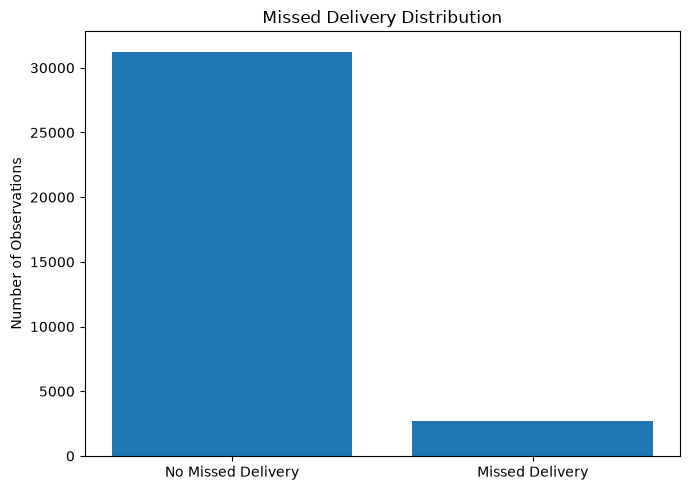

In [6]:
target_counts = (
    df["missed_delivery"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Missed Delivery", "Missed Delivery"],
    target_counts.values
)

plt.title("Missed Delivery Distribution")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

## 4. Missed Delivery Severity

Missed Deliveries are not equally important from an operational perspective.

The number of lost pieces is therefore analysed to distinguish low-volume delivery failures from severe high-volume events.

In [7]:
missed_df = df[
    df["missed_delivery"] == 1
].copy()

missed_df["lost"].describe()

count     2715.000000
mean       509.249724
std        846.671725
min          1.000000
25%         72.000000
50%        208.000000
75%        576.000000
max      12600.000000
Name: lost, dtype: float64

In [8]:
lost_percentiles = (
    missed_df["lost"]
    .quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)

lost_percentiles

0.50     208.0
0.75     576.0
0.90    1341.2
0.95    1980.0
0.99    4095.0
Name: lost, dtype: float64

### Lost Quantity Distribution

The distribution of lost quantity is strongly right-skewed.

To avoid extreme observations dominating the visualization, the histogram is restricted to observations below the 99th percentile.

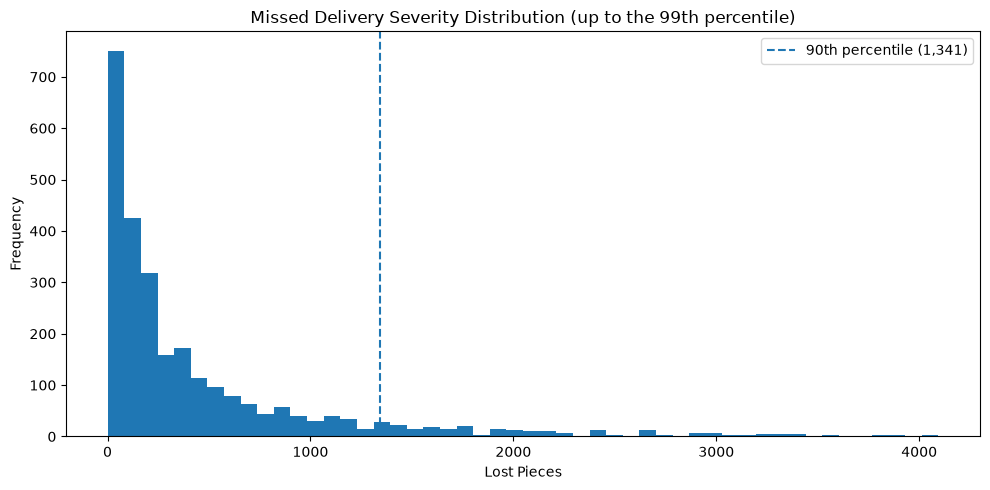

In [9]:
q90 = missed_df["lost"].quantile(0.90)
q99 = missed_df["lost"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    missed_df.loc[
        missed_df["lost"] <= q99,
        "lost"
    ],
    bins=50
)

plt.axvline(
    q90,
    linestyle="--",
    label=f"90th percentile ({q90:,.0f})"
)

plt.xlabel("Lost Pieces")
plt.ylabel("Frequency")

plt.title(
    "Missed Delivery Severity Distribution "
    "(up to the 99th percentile)"
)

plt.legend()

plt.tight_layout()
plt.show()

### High-Volume Missed Deliveries

For exploratory purposes, a High-Volume Missed Delivery is defined as a Missed Delivery whose lost quantity is equal to or greater than the 90th percentile of the Missed Delivery severity distribution.

This threshold does not represent a definitive operational business rule. It is used to isolate the most severe 10% of delivery failures and analyse whether their operational characteristics differ from other Missed Deliveries.

In [10]:
high_volume_threshold = (
    missed_df["lost"]
    .quantile(0.90)
)

print(
    f"High-volume MD threshold: "
    f"{high_volume_threshold:,.0f} lost pieces"
)

High-volume MD threshold: 1,341 lost pieces


In [11]:
df["high_volume_md"] = (
    (df["missed_delivery"] == 1)
    &
    (df["lost"] >= high_volume_threshold)
).astype(int)

## 5. Operational Compliance Indicators

The operational compliance indicators are compared between observations with and without Missed Deliveries.

Because these variables contain strongly skewed distributions and extreme observations, medians are used as the primary descriptive statistic.

In [12]:
ratio_comparison = (
    df.groupby("missed_delivery")[
        operational_ratio_cols
    ]
    .median()
    .T
)

ratio_comparison.columns = [
    "No Missed Delivery",
    "Missed Delivery"
]

ratio_comparison["difference"] = (
    ratio_comparison["Missed Delivery"]
    - ratio_comparison["No Missed Delivery"]
)

ratio_comparison

,No Missed Delivery,Missed Delivery,difference
CumpFabRit,94.000000,90.199997,-3.800003
CumpExpDem,84.599998,77.000000,-7.599998
CumpStock,107.199997,82.300003,-24.899994
PorcenCump,94.699997,91.099998,-3.599998
PorcenCumpto,96.300003,92.599998,-3.700005
CumpTotal,100.000000,101.900002,1.900002


### Distribution of Compliance Indicators

Boxplots are used to compare the distribution of each operational compliance indicator between Missed Delivery and non-Missed Delivery observations.

Observations above the 99th percentile are excluded from the visualization only, in order to improve readability. No observations are removed from the dataset.

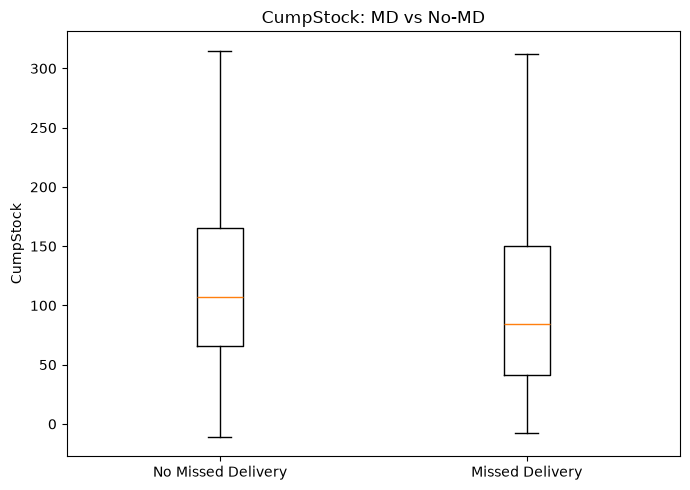

In [13]:
col = "CumpStock"

lower = df[col].quantile(0.01)
upper = df[col].quantile(0.99)
plot_df = df[df[col].between(lower, upper)]

no_md = plot_df.loc[plot_df["missed_delivery"] == 0, col]
md_values = plot_df.loc[plot_df["missed_delivery"] == 1, col]

plt.figure(figsize=(7, 5))
plt.boxplot(
    [no_md, md_values],
    tick_labels=["No Missed Delivery", "Missed Delivery"],
    showfliers=False
)
plt.title("CumpStock: MD vs No-MD")
plt.ylabel("CumpStock")
plt.tight_layout()
plt.show()


## 6. Absolute Operational Variables

Ratios describe relative operational compliance, but they do not preserve information about operational scale.

For example, a 50% production compliance ratio may correspond to a deficit of 10 pieces or a deficit of several thousand pieces.

Absolute production, demand and stock variables are therefore compared between Missed Delivery and non-Missed Delivery observations.

In [14]:
absolute_comparison = (
    df.groupby("missed_delivery")[
        operational_absolute_cols
    ]
    .median()
    .T
)

absolute_comparison.columns = [
    "No missed delivery",
    "Missed Delivery"
]

absolute_comparison["difference"] = (
    absolute_comparison["Missed Delivery"]
    - absolute_comparison["No missed delivery"]
)
absolute_comparison

,No missed delivery,Missed Delivery,difference
FabricacionSemana,555.0,551.0,-4.0
RitmoSemana,600.0,598.0,-2.0
ExpedidasSemana,540.0,600.0,60.0
Demanda,845.0,970.0,125.0
StockFin,573.0,638.0,65.0
StockReal,615.0,564.0,-51.0
AcumFab,1100.0,1131.0,31.0
AcumRitmo,1170.0,1160.0,-10.0
AcumEnvio,1064.0,1080.0,16.0
AcumDemanda,1148.0,1110.0,-38.0


### Absolute Operational Variables - Initial Findings

The comparison of absolute operational variables suggests that Missed Delivery observations are associated with a different demand-stock balance.

Median current demand increases from approximately 845 pieces for observations without a Missed Delivery to approximately 970 pieces for Missed Delivery observations.

At the same time, median actual stock decreases from approximately 615 to 564 pieces.

In contrast, weekly production and production rhythm remain relatively similar between both groups.

These results suggest that Missed Deliveries may be more closely associated with demand and stock pressure than with absolute weekly production volume alone.

## 7. Operational Gap Engineering for EDA

Absolute variables are combined into interpretable operational gaps.

These exploratory variables represent the difference between actual and expected operational conditions.

A negative gap indicates that the observed operational value is below the corresponding requirement or reference value.

In [15]:
df["production_gap"] = (
    df["FabricacionSemana"]
    - df["RitmoSemana"]
)

df["shipment_demand_gap"] = (
    df["ExpedidasSemana"]
    - df["Demanda"]
)

df["stock_gap"] = (
    df["StockReal"]
    - df["StockFin"]
)

df["accumulated_production_gap"] = (
    df["AcumFab"]
    - df["AcumRitmo"]
)

df["accumulated_delivery_gap"] = (
    df["AcumEnvio"]
    - df["AcumDemanda"]
)

df["planned_delivery_gap"] = (
    df["EntregasPrev"]
    - df["DemandActual"]
)

In [16]:
gap_cols = [
    "production_gap",
    "shipment_demand_gap",
    "stock_gap",
    "accumulated_production_gap",
    "accumulated_delivery_gap",
    "planned_delivery_gap"
]

### Operational Gaps and Missed Deliveries

The median operational gaps are compared between successful observations and Missed Deliveries.

This provides a business-oriented interpretation of operational deficits associated with delivery failures.

In [17]:
gap_comparison = (
    df.groupby("missed_delivery")[
        gap_cols
    ]
    .median()
    .T
)

gap_comparison.columns = [
    "No Missed Delivery",
    "Missed Delivery"
]

gap_comparison["difference"] = (
    gap_comparison["Missed Delivery"]
    - gap_comparison["No Missed Delivery"]
)

gap_comparison

,No Missed Delivery,Missed Delivery,difference
production_gap,-3.0,-4.0,-1.0
shipment_demand_gap,-89.0,-144.0,-55.0
stock_gap,30.0,-40.0,-70.0
accumulated_production_gap,-17.0,-24.0,-7.0
accumulated_delivery_gap,-10.0,-7.0,3.0
planned_delivery_gap,0.0,66.0,66.0


## 8. High-Volume Missed Delivery Analysis

The most severe Missed Deliveries are analysed separately to investigate whether their operational characteristics differ from lower-volume Missed Deliveries.

In [18]:
high_volume_ratio_comparison = (
    df[
        df["missed_delivery"] == 1
    ]
    .groupby("high_volume_md")[
        operational_ratio_cols
    ]
    .median()
    .T
)

high_volume_ratio_comparison.columns = [
    "Regular MD",
    "High-volume MD"
]

high_volume_ratio_comparison[
    "difference"
] = (
    high_volume_ratio_comparison[
        "High-volume MD"
    ]
    - high_volume_ratio_comparison[
        "Regular MD"
    ]
)

high_volume_ratio_comparison

,Regular MD,High-volume MD,difference
CumpFabRit,89.699997,95.300003,5.600006
CumpExpDem,77.400002,73.199997,-4.200005
CumpStock,81.699997,83.900002,2.200005
PorcenCump,90.699997,93.099998,2.400002
PorcenCumpto,93.300003,87.199997,-6.100006
CumpTotal,101.599998,106.900002,5.300003


In [19]:
high_volume_absolute_comparison = (
    df[
        df["missed_delivery"] == 1
    ]
    .groupby("high_volume_md")[
        operational_absolute_cols
    ]
    .median()
    .T
)

high_volume_absolute_comparison.columns = [
    "Regular MD",
    "High-volume MD"
]

high_volume_absolute_comparison[
    "difference"
] = (
    high_volume_absolute_comparison[
        "High-volume MD"
    ]
    - high_volume_absolute_comparison[
        "Regular MD"
    ]
)

high_volume_absolute_comparison

,Regular MD,High-volume MD,difference
FabricacionSemana,466.0,2050.5,1584.5
RitmoSemana,495.0,2025.0,1530.0
ExpedidasSemana,530.0,1728.0,1198.0
Demanda,870.0,3050.0,2180.0
StockFin,546.0,2228.5,1682.5
StockReal,496.0,1587.0,1091.0
AcumFab,975.0,4060.0,3085.0
AcumRitmo,990.0,4385.0,3395.0
AcumEnvio,960.0,4040.0,3080.0
AcumDemanda,970.0,4275.5,3305.5


In [20]:
high_volume_gap_comparison = (
    df[
        df["missed_delivery"] == 1
    ]
    .groupby("high_volume_md")[
        gap_cols
    ]
    .median()
    .T
)

high_volume_gap_comparison.columns = [
    "Regular MD",
    "High-volume MD"
]

high_volume_gap_comparison[
    "difference"
] = (
    high_volume_gap_comparison[
        "High-volume MD"
    ]
    - high_volume_gap_comparison[
        "Regular MD"
    ]
)

high_volume_gap_comparison

,Regular MD,High-volume MD,difference
production_gap,-1.0,-35.5,-34.5
shipment_demand_gap,-130.0,-573.0,-443.0
stock_gap,-36.0,-81.0,-45.0
accumulated_production_gap,-16.0,-180.5,-164.5
accumulated_delivery_gap,-1.0,-312.0,-311.0
planned_delivery_gap,49.0,756.0,707.0


### High-Volume Missed Delivery Findings

High-volume Missed Deliveries occur under substantially larger operational scale than regular Missed Deliveries.

Median demand, production rhythm, stock quantities and planned deliveries are several times higher for high-volume events.

However, operational scale alone does not fully explain severity.

High-volume Missed Deliveries also present larger fulfilment deficits. The median `shipment_demand_gap` decreases from approximately -130 pieces for regular Missed Deliveries to approximately -573 pieces for high-volume events.

Similarly, the accumulated delivery gap decreases substantially, indicating that severe delivery failures are associated with both high operational exposure and stronger demand-fulfilment pressure.

Therefore, Missed Delivery occurrence and severity appear to represent partially different analytical problems.


## 9. Multivariable Relationships

The relationships between numerical operational variables are explored using Spearman rank correlation.

Spearman correlation is preferred over Pearson correlation for the initial EDA because several variables present skewed distributions, extreme observations and potentially non-linear monotonic relationships.

Correlation does not imply causation. The objective is to identify potentially informative relationships for subsequent statistical and predictive analysis.

In [21]:
predictor_cols = (
    operational_absolute_cols
    + operational_ratio_cols
    + gap_cols
)

predictor_corr = (
    df[predictor_cols + ["missed_delivery"]]
    .corr(method="spearman")
)

target_corr_summary = pd.DataFrame({
    "spearman_corr": predictor_corr["missed_delivery"].drop("missed_delivery")
})
target_corr_summary["abs_corr"] = target_corr_summary["spearman_corr"].abs()
target_corr_summary = target_corr_summary.sort_values("abs_corr", ascending=False)
target_corr_summary


,spearman_corr,abs_corr
CumpStock,-0.087473,0.087473
planned_delivery_gap,0.073703,0.073703
CumpTotal,0.069999,0.069999
stock_gap,-0.049318,0.049318
EntregasPrev,0.036314,0.036314
StockReal,-0.028311,0.028311
Demanda,0.025582,0.025582
PorcenCump,-0.025340,0.025340
PorcenCumpto,-0.023532,0.023532
DemandActual,0.022504,0.022504


### Correlation with Missed Delivery Occurrence

Individual Spearman correlations with the Missed Delivery target are relatively weak.

The strongest association is observed for `CumpStock`, followed by `planned_delivery_gap`, `CumpTotal` and `stock_gap`. However, none of the individual variables presents a strong monotonic relationship with the target.

This suggests that Missed Delivery occurrence is unlikely to be explained by a single operational variable and may instead depend on interactions between several operational conditions and their temporal evolution.


### Correlation with Missed Delivery Severity

The previous analysis evaluates whether operational variables are associated with the occurrence of a Missed Delivery.

A different question is whether these variables are associated with the severity of the event once a Missed Delivery has occurred.

For this reason, the following analysis is restricted to Missed Delivery observations and uses lost quantity as the severity measure.


In [22]:
severity_corr = (
    df.loc[df["missed_delivery"] == 1, predictor_cols + ["lost"]]
    .corr(method="spearman")["lost"]
    .drop("lost")
    .sort_values()
)
severity_corr


shipment_demand_gap          -0.186977
accumulated_delivery_gap     -0.135444
accumulated_production_gap   -0.096864
CumpStock                    -0.070108
PorcenCumpto                 -0.065671
stock_gap                    -0.055638
production_gap               -0.052302
CumpExpDem                   -0.044590
CumpFabRit                    0.027926
PorcenCump                    0.035405
CumpTotal                     0.080270
planned_delivery_gap          0.168379
ExpedidasSemana               0.289655
AcumEnvio                     0.314044
FabricacionSemana             0.355601
AcumFab                       0.357435
AcumDemanda                   0.367895
StockReal                     0.373183
AcumRitmo                     0.374199
RitmoSemana                   0.384822
StockFin                      0.416989
DemandActual                  0.467832
Demanda                       0.476560
EntregasPrev                  0.497639
Name: lost, dtype: float64

### Severity Correlation Findings

Missed Delivery severity presents substantially stronger associations with operational scale than Missed Delivery occurrence.

The strongest positive relationships with lost quantity are observed for planned deliveries, demand, current demand, stock and production-related variables. In particular, `EntregasPrev`, `Demanda` and `DemandActual` show moderate positive correlations with lost quantity.

Negative associations are observed for `shipment_demand_gap` and `accumulated_delivery_gap`, suggesting that larger fulfilment deficits tend to accompany more severe Missed Deliveries.

These results indicate that severe Missed Deliveries may emerge from the combination of high operational exposure and insufficient fulfilment capacity. Because lost quantity is absolute, part of these associations may also reflect operational scale.


## Selected Visual Relationships

Representative variables are visualized to complement the numerical comparisons. Values outside the 1st and 99th percentiles are excluded only from these plots to improve readability.


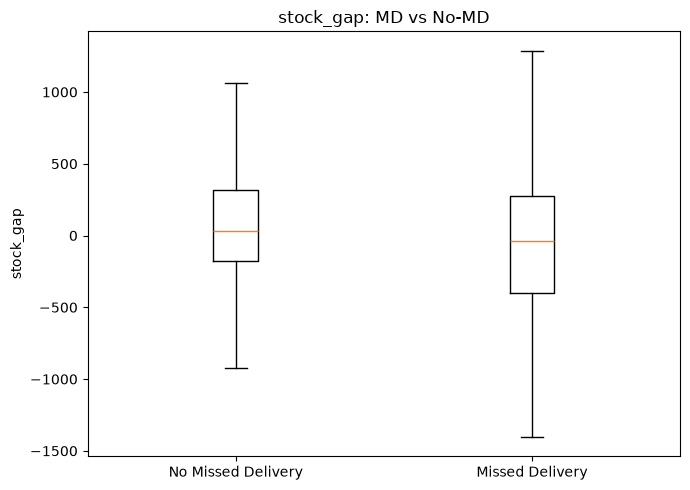

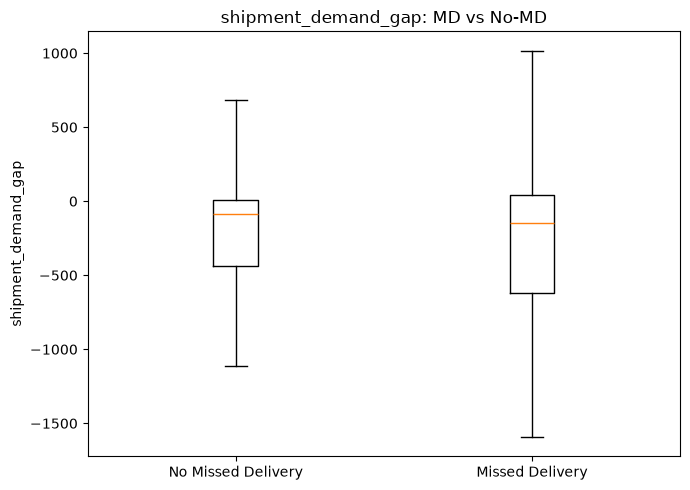

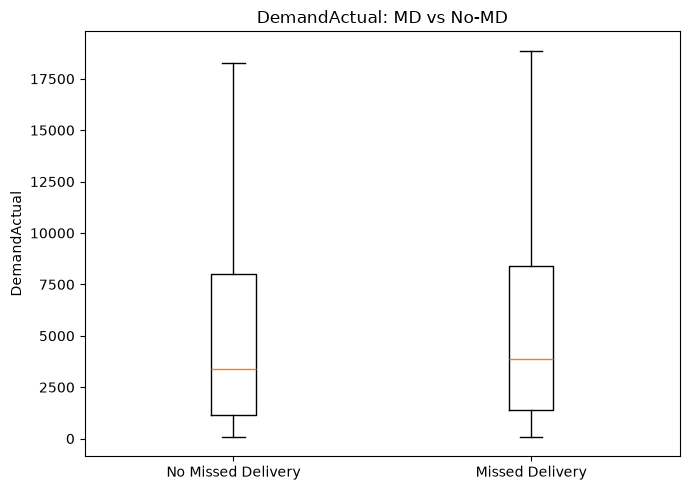

In [23]:
selected_variables = [
    "stock_gap",
    "shipment_demand_gap",
    "DemandActual"
]

for col in selected_variables:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    plot_df = df[df[col].between(lower, upper)]
    no_md = plot_df.loc[plot_df["missed_delivery"] == 0, col]
    md_values = plot_df.loc[plot_df["missed_delivery"] == 1, col]

    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [no_md, md_values],
        tick_labels=["No Missed Delivery", "Missed Delivery"],
        showfliers=False
    )
    plt.title(f"{col}: MD vs No-MD")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### Selected Operational Relationships

Selected scatterplots are used to investigate potentially relevant relationships identified through the correlation analysis.

A random sample is used only for visualization to avoid excessive point overlap.

In [24]:
sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

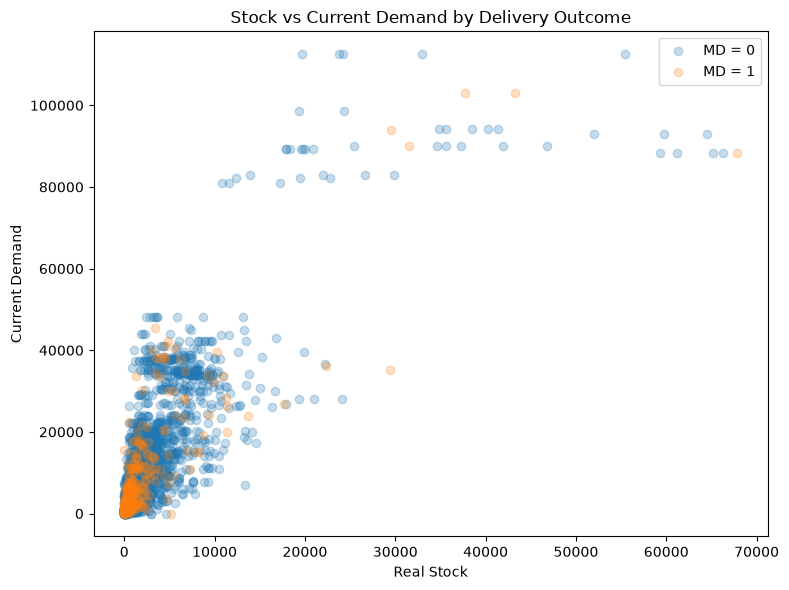

In [25]:
plt.figure(figsize=(8, 6))

for label, group in sample_df.groupby(
    "missed_delivery"
):

    plt.scatter(
        group["StockReal"],
        group["DemandActual"],
        alpha=0.25,
        label=f"MD = {label}"
    )

plt.xlabel("Real Stock")
plt.ylabel("Current Demand")

plt.title(
    "Stock vs Current Demand "
    "by Delivery Outcome"
)

plt.legend()

plt.tight_layout()
plt.show()

## 10. Planning Group Analysis

Planning groups are analysed using both frequency and volume-based metrics.

This distinction allows high-frequency problem groups to be differentiated from high-volume problem groups.

In [26]:
group_summary = (
    df.groupby("Grupo_raiz")
    .agg(
        records=(
            "missed_delivery",
            "size"
        ),

        missed_deliveries=(
            "missed_delivery",
            "sum"
        ),

        lost_pieces=(
            "lost",
            "sum"
        ),

        requested_pieces=(
            "requested",
            "sum"
        )
    )
)

In [27]:
group_summary["md_rate"] = (
    group_summary["missed_deliveries"]
    / group_summary["records"]
    * 100
)

group_summary["quantity_miss_rate"] = (
    group_summary["lost_pieces"]
    / group_summary["requested_pieces"]
    * 100
)

In [28]:
top_groups_lost = (
    group_summary
    .sort_values(
        "lost_pieces",
        ascending=False
    )
    .head(15)
)

top_groups_lost

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
Grupo_raiz,,,,,,
8258OA0AQ,172,75,110387,364883,43.604651,30.252711
B946M0010,366,42,101160,1648260,11.475410,6.137381
7922S,146,69,98334,181350,47.260274,54.223325
8257O00AQ,170,64,50534,183926,37.647059,27.475180
8850T004A,85,24,45960,240660,28.235294,19.097482
8492O,160,52,45216,164304,32.500000,27.519720
B971M0010,193,61,43140,209240,31.606218,20.617473
7054O0010,210,45,36091,146482,21.428571,24.638522
7901O,150,41,34248,147810,27.333333,23.170286


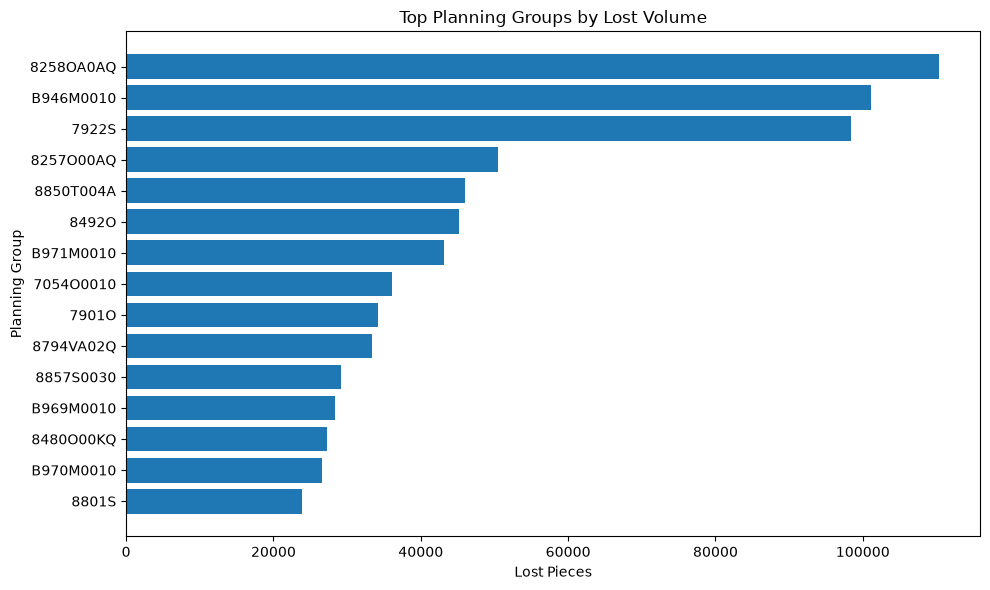

In [29]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_groups_lost.index.astype(str),
    top_groups_lost["lost_pieces"]
)

plt.gca().invert_yaxis()

plt.xlabel("Lost Pieces")
plt.ylabel("Planning Group")

plt.title(
    "Top Planning Groups by Lost Volume"
)

plt.tight_layout()
plt.show()

### Relative Planning Group Impact

Relative failure rates may be misleading for planning groups with very few observations.

A minimum number of historical observations is therefore required before ranking planning groups by relative failure rate.

In [30]:
MIN_GROUP_RECORDS = 100

In [31]:
group_filtered = (
    group_summary[
        group_summary["records"]
        >= MIN_GROUP_RECORDS
    ]
)

In [32]:
group_filtered.sort_values(
    "quantity_miss_rate",
    ascending=False
).head(15)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
Grupo_raiz,,,,,,
7922S,146,69,98334,181350,47.260274,54.223325
8480I002Q,150,60,22673,58581,40.000000,38.703675
8291OI01Q,146,49,12545,36145,33.561644,34.707428
8291OK01Q,131,44,7772,22580,33.587786,34.419841
8258OA0AQ,172,75,110387,364883,43.604651,30.252711
8480O00KQ,161,49,27219,90927,30.434783,29.935003
7047S0010,106,44,16506,59340,41.509434,27.815976
8492O,160,52,45216,164304,32.500000,27.519720
8257O00AQ,170,64,50534,183926,37.647059,27.475180


## 11. Customer, UAT and Destination Analysis

Customer, UAT and destination dimensions are analysed to identify whether Missed Delivery impact is concentrated in specific logistical flows.

In [33]:
def summarize_dimension(
    dataframe,
    column
):

    summary = (
        dataframe.groupby(column)
        .agg(
            records=(
                "missed_delivery",
                "size"
            ),

            missed_deliveries=(
                "missed_delivery",
                "sum"
            ),

            lost_pieces=(
                "lost",
                "sum"
            ),

            requested_pieces=(
                "requested",
                "sum"
            )
        )
    )

    summary["md_rate"] = (
        summary["missed_deliveries"]
        / summary["records"]
        * 100
    )

    summary["quantity_miss_rate"] = (
        summary["lost_pieces"]
        / summary["requested_pieces"]
        * 100
    )

    return summary

In [34]:
uat_summary = summarize_dimension(
    df,
    "uat"
)

customer_summary = summarize_dimension(
    df,
    "customer"
)

destination_summary = summarize_dimension(
    df,
    "destination"
)

In [35]:
uat_summary.sort_values(
    "lost_pieces",
    ascending=False
).head(10)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
uat,,,,,,
UATE2,2279,465,372808,1524743,20.403686,24.450547
UATZ2,1504,306,167542,1553510,20.345745,10.784739
UATP11,1488,152,117753,597743,10.215054,19.699603
UATE5,3928,180,115486,2317873,4.582485,4.982413
UATM19,3711,97,104876,2124461,2.613851,4.936593
UATP19,1833,132,95231,1345425,7.201309,7.078135
UATE3,1497,287,91264,636030,19.171677,14.349009
UATP21,3136,132,51552,2118738,4.209184,2.433147
UATP15,927,119,49220,421284,12.837109,11.683330


In [36]:
uat_summary[
    uat_summary["records"] >= 100
].sort_values(
    "quantity_miss_rate",
    ascending=False
).head(10)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
uat,,,,,,
UATE9,186,73,23585,62837,39.247312,37.533619
UATE2,2279,465,372808,1524743,20.403686,24.450547
UATP11,1488,152,117753,597743,10.215054,19.699603
UATE3,1497,287,91264,636030,19.171677,14.349009
UATP15,927,119,49220,421284,12.837109,11.683330
UATZ2,1504,306,167542,1553510,20.345745,10.784739
UATP19,1833,132,95231,1345425,7.201309,7.078135
UATZ3,1238,99,45975,666647,7.996769,6.896453
UATZ5,883,34,39712,675671,3.850510,5.877417


In [37]:
customer_summary.sort_values(
    "lost_pieces",
    ascending=False
).head(10)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
customer,,,,,,
432008,1783,449,254502,983682,25.182277,25.872386
432005,845,254,172019,664550,30.059172,25.885035
432003,169,82,106254,196710,48.520710,54.015556
091A18,358,99,82040,633180,27.653631,12.956821
030237,1298,110,79596,1298184,8.474576,6.131334
073D61,266,85,78991,265009,31.954887,29.806912
093843,910,52,69529,1728807,5.714286,4.021791
B99E31,146,37,57636,578328,25.342466,9.965971
091967,170,21,50160,879240,12.352941,5.704927


In [38]:
customer_summary[
    customer_summary["records"] >= 100
].sort_values(
    "quantity_miss_rate",
    ascending=False
).head(10)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
customer,,,,,,
432003,169,82,106254,196710,48.520710,54.015556
073D61,266,85,78991,265009,31.954887,29.806912
093C77,179,62,26885,101519,34.636872,26.482727
432005,845,254,172019,664550,30.059172,25.885035
432008,1783,449,254502,983682,25.182277,25.872386
092A63,116,25,13528,64448,21.551724,20.990566
092C17,123,22,16755,103796,17.886179,16.142241
091A18,358,99,82040,633180,27.653631,12.956821
092A23,333,35,3840,31616,10.510511,12.145749


In [39]:
destination_summary.sort_values(
    "lost_pieces",
    ascending=False
).head(10)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
destination,,,,,,
432008D01,1295,449,254502,871460,34.671815,29.204094
432005D01,845,254,172019,664550,30.059172,25.885035
091A18D01,331,92,81480,621970,27.794562,13.100310
073D61D01,266,85,78991,265009,31.954887,29.806912
432003D01,153,67,72544,160120,43.790850,45.306020
093843D09,904,50,69424,1728585,5.530973,4.016233
B99E31D01,146,37,57636,578328,25.342466,9.965971
070C92D01,85,24,45960,240660,28.235294,19.097482
091967D09,95,16,40050,570990,16.842105,7.014133


In [40]:
destination_summary[
    destination_summary["records"] >= 100
].sort_values(
    "quantity_miss_rate",
    ascending=False
).head(10)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
destination,,,,,,
432003D01,153,67,72544,160120,43.790850,45.306020
073D61D01,266,85,78991,265009,31.954887,29.806912
432008D01,1295,449,254502,871460,34.671815,29.204094
091870D10,170,86,18810,65760,50.588235,28.604015
093C77D03,179,62,26885,101519,34.636872,26.482727
432005D01,845,254,172019,664550,30.059172,25.885035
092C17D01,123,22,16755,103796,17.886179,16.142241
091A18D01,331,92,81480,621970,27.794562,13.100310
092A23D03,333,35,3840,31616,10.510511,12.145749


## 12. Critical Flow Analysis

Planning group, UAT and destination information are combined to identify specific logistical flows associated with high Missed Delivery impact.

A minimum historical support threshold is used to avoid prioritizing combinations based on very few observations.

In [41]:
flow_summary = (
    df.groupby(
        [
            "Grupo_raiz",
            "uat",
            "destination"
        ]
    )
    .agg(
        records=(
            "missed_delivery",
            "size"
        ),

        missed_deliveries=(
            "missed_delivery",
            "sum"
        ),

        lost_pieces=(
            "lost",
            "sum"
        ),

        requested_pieces=(
            "requested",
            "sum"
        )
    )
)

In [42]:
flow_summary["md_rate"] = (
    flow_summary["missed_deliveries"]
    / flow_summary["records"]
    * 100
)

flow_summary["quantity_miss_rate"] = (
    flow_summary["lost_pieces"]
    / flow_summary["requested_pieces"]
    * 100
)

### Minimum Historical Support

Flow-level failure rates can become unstable when they are calculated from very few observations.

For this exploratory analysis, only flows with at least 30 historical observations are considered when ranking relative Missed Delivery performance.

This threshold is used as a descriptive stability criterion and does not represent a definitive operational business rule.

In [43]:
flow_filtered = (
    flow_summary[
        flow_summary["records"] >= 30
    ]
)

In [44]:
flow_filtered.sort_values(
    "lost_pieces",
    ascending=False
).head(20)

,,,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
Grupo_raiz,uat,destination,,,,,,
8258OA0AQ,UATE2,432008D01,172,75,110387,364883,43.604651,30.252711
7922S,UATP11,432003D01,131,55,65224,145360,41.984733,44.870666
B946M0010,UATM19,B99E31D01,73,21,51000,537420,28.767123,9.489785
8257O00AQ,UATE2,432008D01,170,64,50534,183926,37.647059,27.475180
8850T004A,UATE5,070C92D01,85,24,45960,240660,28.235294,19.097482
8492O,UATE2,432005D01,160,52,45216,164304,32.500000,27.519720
B946M0010,UATM19,091967D09,95,16,40050,570990,16.842105,7.014133
7054O0010,UATE2,432005D01,210,45,36091,146482,21.428571,24.638522
B971M0010,UATZ2,091A18D01,101,33,34500,179810,32.673267,19.186920


In [45]:
flow_filtered.sort_values(
    "quantity_miss_rate",
    ascending=False
).head(20)

,,,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
Grupo_raiz,uat,destination,,,,,,
B971M0010,UATZ2,091870D10,54,25,8280,15300,46.296296,54.117647
B970M0010,UATZ2,091870D10,39,22,6060,11490,56.410256,52.741514
8244S,UATP15,094D29D02,46,25,9855,19845,54.347826,49.659864
8010W058Q,UATT11,432005D01,36,18,1358,2953,50.000000,45.987132
8010W024Q,UATT11,432005D01,68,34,5176,11319,50.000000,45.728421
7922S,UATP11,432003D01,131,55,65224,145360,41.984733,44.870666
10137T00G0,UATE2,073D61D01,32,10,4169,9377,31.250000,44.459849
8242S,UATP15,094D29D02,42,19,6048,14178,45.238095,42.657639
8480I002Q,UATE9,432008D01,150,60,22673,58581,40.000000,38.703675


In [46]:
display(
    uat_summary
    .sort_values("lost_pieces", ascending=False)
    .head(10)
)

display(
    customer_summary
    .sort_values("lost_pieces", ascending=False)
    .head(10)
)

display(
    destination_summary
    .sort_values("lost_pieces", ascending=False)
    .head(10)
)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
uat,,,,,,
UATE2,2279,465,372808,1524743,20.403686,24.450547
UATZ2,1504,306,167542,1553510,20.345745,10.784739
UATP11,1488,152,117753,597743,10.215054,19.699603
UATE5,3928,180,115486,2317873,4.582485,4.982413
UATM19,3711,97,104876,2124461,2.613851,4.936593
UATP19,1833,132,95231,1345425,7.201309,7.078135
UATE3,1497,287,91264,636030,19.171677,14.349009
UATP21,3136,132,51552,2118738,4.209184,2.433147
UATP15,927,119,49220,421284,12.837109,11.683330


,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
customer,,,,,,
432008,1783,449,254502,983682,25.182277,25.872386
432005,845,254,172019,664550,30.059172,25.885035
432003,169,82,106254,196710,48.520710,54.015556
091A18,358,99,82040,633180,27.653631,12.956821
030237,1298,110,79596,1298184,8.474576,6.131334
073D61,266,85,78991,265009,31.954887,29.806912
093843,910,52,69529,1728807,5.714286,4.021791
B99E31,146,37,57636,578328,25.342466,9.965971
091967,170,21,50160,879240,12.352941,5.704927


,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
destination,,,,,,
432008D01,1295,449,254502,871460,34.671815,29.204094
432005D01,845,254,172019,664550,30.059172,25.885035
091A18D01,331,92,81480,621970,27.794562,13.100310
073D61D01,266,85,78991,265009,31.954887,29.806912
432003D01,153,67,72544,160120,43.790850,45.306020
093843D09,904,50,69424,1728585,5.530973,4.016233
B99E31D01,146,37,57636,578328,25.342466,9.965971
070C92D01,85,24,45960,240660,28.235294,19.097482
091967D09,95,16,40050,570990,16.842105,7.014133


### Customer, UAT and Destination Findings

The analysis of logistical dimensions reveals a strong concentration of Missed Delivery impact in specific UATs, customers and destinations.

`UATE2` presents the highest absolute lost volume among UATs, with more than 370,000 lost pieces and a Quantity Miss Rate above 24%. Other UATs show different combinations of frequency and severity, confirming that absolute lost volume and relative failure rate provide complementary information.

At customer level, several customers combine high Missed Delivery frequency with substantial lost volume. In particular, customer `432003` presents a Quantity Miss Rate above 50%, indicating that more than half of the requested volume associated with the analysed observations was lost.

A similar pattern is observed at destination level. Certain destinations present both high Missed Delivery frequency and high volumetric impact, suggesting that delivery failures may be concentrated in specific logistical flows rather than uniformly distributed across the network.

These results support the subsequent analysis of combined planning-group, UAT and destination flows.

## 13. Pareto Analysis of Lost Volume

The concentration of lost volume across planning groups is analysed using a Pareto approach.

The objective is to determine whether a relatively small proportion of planning groups accounts for most of the lost pieces.

In [47]:
pareto_groups = (
    group_summary
    .sort_values(
        "lost_pieces",
        ascending=False
    )
    .copy()
)

pareto_groups[
    "cumulative_lost"
] = (
    pareto_groups[
        "lost_pieces"
    ].cumsum()
)

pareto_groups[
    "cumulative_lost_pct"
] = (
    pareto_groups[
        "cumulative_lost"
    ]
    / pareto_groups[
        "lost_pieces"
    ].sum()
    * 100
)

In [48]:
groups_to_80 = (
    pareto_groups[
        pareto_groups[
            "cumulative_lost_pct"
        ] < 80
    ].shape[0]
    + 1
)

groups_to_80_pct = (
    groups_to_80
    / len(pareto_groups)
    * 100
)

print(
    f"{groups_to_80} planning groups "
    f"({groups_to_80_pct:.2f}% of all groups) "
    "account for approximately "
    "80% of lost pieces."
)

43 planning groups (19.03% of all groups) account for approximately 80% of lost pieces.


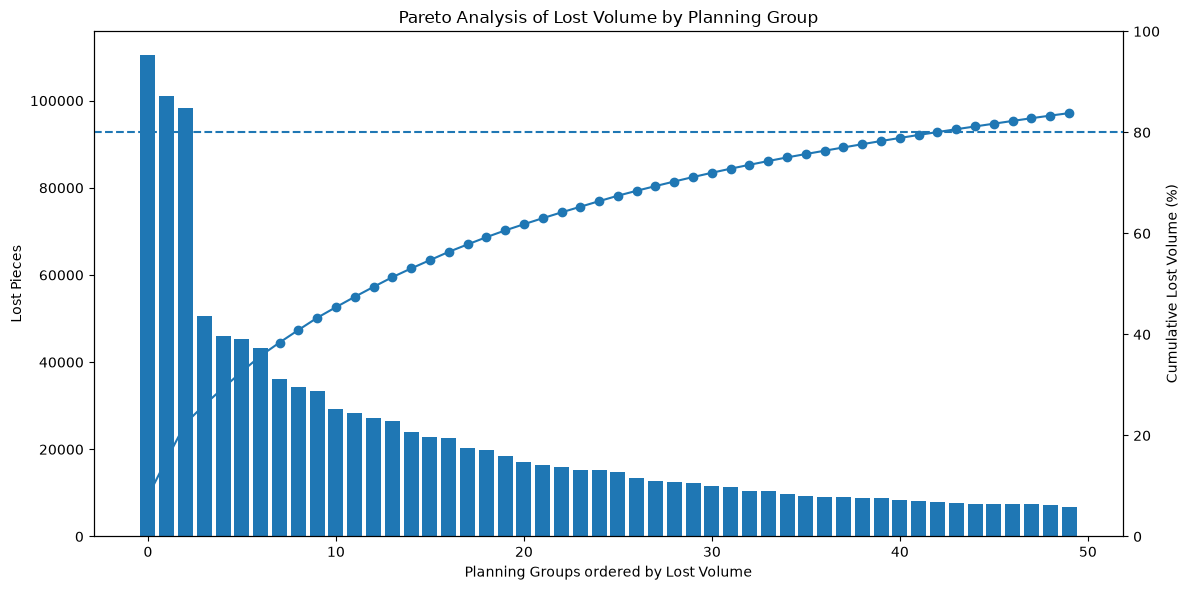

In [49]:
pareto_plot = pareto_groups.reset_index()
top_n = 50
plot_data = pareto_plot.head(top_n)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(np.arange(len(plot_data)), plot_data["lost_pieces"])
ax1.set_xlabel("Planning Groups ordered by Lost Volume")
ax1.set_ylabel("Lost Pieces")

ax2 = ax1.twinx()
ax2.plot(np.arange(len(plot_data)), plot_data["cumulative_lost_pct"], marker="o")
ax2.axhline(80, linestyle="--")
ax2.set_ylabel("Cumulative Lost Volume (%)")
ax2.set_ylim(0, 100)

plt.title("Pareto Analysis of Lost Volume by Planning Group")
plt.tight_layout()
plt.show()


### Pareto Findings

Lost volume presents a strong concentration across planning groups.

Only 43 of the 226 planning groups, corresponding to approximately 19.03% of the analysed portfolio, account for around 80% of all historically lost pieces.

This concentration is close to the classical Pareto 80/20 pattern and indicates that operational improvement actions could potentially focus on a relatively limited subset of planning groups while addressing a substantial proportion of total lost volume.


## 14. Temporal Evolution

The available dataset contains the complete year 2025 and only part of 2026.

Therefore, the historical period is not sufficient to establish robust annual seasonality.

The temporal analysis is limited to identifying changes, peaks and anomalous periods in Missed Delivery performance.

In [50]:
df["year_month"] = (
    df["Fecha"]
    .dt.to_period("M")
)

In [51]:
monthly_summary = (
    df.groupby("year_month")
    .agg(
        records=(
            "missed_delivery",
            "size"
        ),

        missed_deliveries=(
            "missed_delivery",
            "sum"
        ),

        lost_pieces=(
            "lost",
            "sum"
        ),

        requested_pieces=(
            "requested",
            "sum"
        )
    )
)

In [52]:
monthly_summary["md_rate"] = (
    monthly_summary[
        "missed_deliveries"
    ]
    / monthly_summary[
        "records"
    ]
    * 100
)

monthly_summary[
    "quantity_miss_rate"
] = (
    monthly_summary[
        "lost_pieces"
    ]
    / monthly_summary[
        "requested_pieces"
    ]
    * 100
)

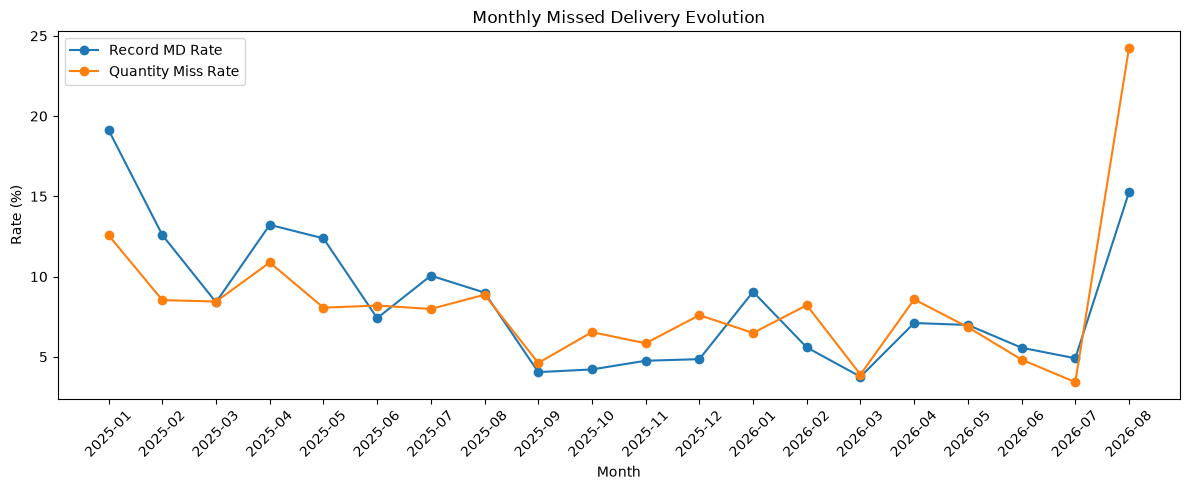

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["md_rate"],
    marker="o",
    label="Record MD Rate"
)

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary[
        "quantity_miss_rate"
    ],
    marker="o",
    label="Quantity Miss Rate"
)

plt.xticks(rotation=45)

plt.xlabel("Month")
plt.ylabel("Rate (%)")

plt.title(
    "Monthly Missed Delivery Evolution"
)

plt.legend()

plt.tight_layout()
plt.show()

In [54]:
monthly_summary.sort_values(
    "quantity_miss_rate",
    ascending=False
).head(10)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
year_month,,,,,,
2026-08,295,45,44528,183700,15.254237,24.239521
2025-01,1835,351,123773,984862,19.128065,12.567548
2025-04,1792,237,106179,975867,13.225446,10.880479
2025-08,822,74,42529,479523,9.002433,8.869022
2026-04,1801,128,91212,1063190,7.107163,8.579087
2025-02,1724,217,75589,885625,12.587007,8.535102
2025-03,1833,154,80165,949280,8.401528,8.444821
2026-02,1951,109,85879,1045162,5.586879,8.216812
2025-06,1943,144,86097,1050504,7.411220,8.195780


In [55]:
monthly_summary.sort_values(
    "md_rate",
    ascending=False
).head(10)

,records,missed_deliveries,lost_pieces,requested_pieces,md_rate,quantity_miss_rate
year_month,,,,,,
2025-01,1835,351,123773,984862,19.128065,12.567548
2026-08,295,45,44528,183700,15.254237,24.239521
2025-04,1792,237,106179,975867,13.225446,10.880479
2025-02,1724,217,75589,885625,12.587007,8.535102
2025-05,1591,197,68762,852721,12.382150,8.063833
2025-07,1700,171,76446,957316,10.058824,7.985451
2026-01,1878,170,65950,1016029,9.052183,6.490956
2025-08,822,74,42529,479523,9.002433,8.869022
2025-03,1833,154,80165,949280,8.401528,8.444821


### Temporal Anomalies and Coverage Caveats

The temporal analysis reveals substantial variation in delivery performance across the historical period.

January 2025 presents the highest observed monthly Missed Delivery frequency, with approximately 19.1% of planning-group/date observations affected by a Missed Delivery and a Quantity Miss Rate of approximately 12.6%.

The available observations for August 2026 present an unusually high Quantity Miss Rate of approximately 24.2%. However, this period is incomplete because the dataset only contains observations up to August 25, 2026. Consequently, this value should be interpreted cautiously and should not be directly compared with complete months.

The difference between event-based and volume-based rates further demonstrates that Missed Delivery frequency and severity represent complementary dimensions of operational performance.

## 15. Key Findings

The Exploratory Data Analysis reveals several relevant patterns associated with Missed Deliveries and their operational impact.

1. Missed Deliveries affect approximately 8% of planning-group/date observations. From a volumetric perspective, approximately 7.5% of all requested pieces are lost, confirming that the problem is relevant both in frequency and business impact.

2. Stock-related conditions provide the clearest descriptive distinction between Missed Delivery and non-Missed Delivery observations. Median `CumpStock` decreases from approximately 107.2% to 82.3%.

3. The absolute stock gap presents the same pattern. Median `stock_gap` changes from approximately +30 pieces for observations without a Missed Delivery to approximately -40 pieces for Missed Delivery observations.

4. Shipment-demand pressure is also higher during Missed Delivery observations. Median `shipment_demand_gap` deteriorates from approximately -89 to -144 pieces.

5. Weekly production volume itself changes very little between Missed Delivery and non-Missed Delivery observations, suggesting that production scale alone does not explain failure occurrence.

6. Individual correlations with Missed Delivery occurrence are weak. The strongest Spearman association is observed for `CumpStock`, but its absolute correlation remains below 0.1. This indicates that Missed Delivery occurrence is likely a multivariate problem rather than the result of a single operational factor.

7. Missed Delivery severity behaves differently from occurrence. Lost quantity presents substantially stronger relationships with operational scale, including demand, planned deliveries, stock and production-related quantities.

8. High-volume Missed Deliveries occur under significantly larger operational scale. Median current demand increases from approximately 3,366 pieces for regular Missed Deliveries to approximately 12,081 pieces for high-volume events.

9. High-volume Missed Deliveries also present substantially larger operational deficits. The median `shipment_demand_gap` deteriorates from approximately -130 to -573 pieces, while the accumulated delivery gap decreases from approximately -1 to -312 pieces.

10. Lost volume is strongly concentrated across the planning portfolio. Only 43 planning groups, representing approximately 19.03% of all analysed planning groups, account for approximately 80% of total lost pieces.

11. Missed Delivery impact is also concentrated in specific logistical dimensions. Several UATs, customers and destinations combine high event frequency with high volumetric failure rates.

12. Customer `432003`, for example, presents a Quantity Miss Rate above 50%, while destination `432003D01` presents a Quantity Miss Rate above 45%, indicating the existence of particularly critical logistical flows.

13. Temporal variation is present across the historical period. January 2025 presents the highest complete-month Missed Delivery frequency. The partial August 2026 period presents an unusually high Quantity Miss Rate but should not be directly compared with complete months.

Overall, the EDA suggests that Missed Delivery occurrence and severity are related but distinct problems. Occurrence appears to be associated particularly with stock and fulfilment conditions, whereas severity is strongly influenced by operational scale combined with fulfilment deficits.


## 16. Hypotheses for Statistical Analysis

Based on the exploratory findings, the following hypotheses will be formally evaluated:

1. The distribution of `CumpStock` differs significantly between Missed Delivery and non-Missed Delivery observations.

2. The distribution of `CumpExpDem` differs significantly between Missed Delivery and non-Missed Delivery observations.

3. The `stock_gap` is significantly lower for Missed Delivery observations.

4. The `shipment_demand_gap` is significantly more negative for Missed Delivery observations.

5. Production-related variables present weaker differences between Missed Delivery and non-Missed Delivery observations than stock and demand-related variables.

6. High-volume Missed Deliveries present significantly different demand, production, stock and fulfilment-gap distributions compared with regular Missed Deliveries.

7. Lost quantity is significantly associated with operational scale variables such as demand and planned deliveries.

8. Missed Delivery impact is non-uniformly distributed across planning groups and logistical dimensions.

The next stage will evaluate these hypotheses using non-parametric statistical tests, categorical association tests and appropriate effect-size measures.
